# Regresja Logistyczna


In [33]:
# --- podstawy ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/processed/epl_features.csv")
RESULTS_PATH = Path("../results/premier_league/logistic_regression/")

In [34]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 114)


,Div,Date,HomeTeam,AwayTeam,Referee,FTHG,FTAG,FTR,HS,AS,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,J Moss,2.0,1.0,H,14.0,4.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,M Jones,2.0,2.0,D,11.0,13.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,M Dean,1.0,2.0,A,14.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [35]:
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}

# kandydaci na cechy:
candidate_cols = [c for c in df.columns if c not in cols_to_exclude]

# wzorce cech predykcyjnych (rynek, forma, sezon, czas)
keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend", "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

# sanity check
print(f"Liczba wybranych cech: {len(X_features)}")
X_features[:10]

Liczba wybranych cech: 37


['Prob_H_b365',
 'Home_GF_last5',
 'Home_GA_last5',
 'Home_GD_last5',
 'Home_Pts_last5',
 'Home_Pts_last10',
 'Home_Pts_trend_3v10',
 'Away_GF_last5',
 'Away_GA_last5',
 'Away_GD_last5']

In [36]:
from sklearn.preprocessing import LabelEncoder


# ============================================
# 1. Przygotowanie celu do klasyfikacji (FTR)
# ============================================
target = "FTR"

# y_log będą etykietami 0, 1, 2 odpowiadającymi H/D/A
le_log = LabelEncoder()
y_log = le_log.fit_transform(df[target])   # np. H,D,A -> 1,0,2 (kolejność alfabetyczna)
le_log.classes_  # zobaczysz np. array(['A', 'D', 'H'], dtype='<U1')

array(['A', 'D', 'H'], dtype=object)

In [37]:
# ============================================
# 2. Podział danych (jak poprzednio)
# ============================================

split_date = pd.Timestamp("2022-07-01")

train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train_clf = X.loc[train_mask].reset_index(drop=True)
X_test_clf  = X.loc[test_mask].reset_index(drop=True)
y_train_clf = y_log[train_mask]
y_test_clf  = y_log[test_mask]

X_train_clf.shape, X_test_clf.shape

((2660, 37), (760, 37))

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


# ============================================
# 3. Model regresji logistycznej
# ============================================

logreg_base = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)
pipe_logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", logreg_base)
])
param_grid = {
    "model__C": [0.008, 0.010, 0.012, 0.014, 0.015]
}
grid_logreg = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Trenowanie GridSearchCV (LogisticRegression, balanced)...")
grid_logreg.fit(X_train_clf, y_train_clf)

print("Najlepsze parametry:", grid_logreg.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_logreg.best_score_)

Trenowanie GridSearchCV (LogisticRegression, balanced)...
Najlepsze parametry: {'model__C': 0.015}
Najlepszy wynik CV (Macro-F1): 0.4904441662572833



=== Logistic Regression (multinomial, balanced) - TEST ===
Accuracy:  0.5263
Macro-F1:  0.4952

=== Classification report ===
              precision    recall  f1-score   support

           A       0.52      0.60      0.56       232
           D       0.27      0.32      0.29       169
           H       0.70      0.57      0.63       359

    accuracy                           0.53       760
   macro avg       0.50      0.50      0.50       760
weighted avg       0.55      0.53      0.53       760



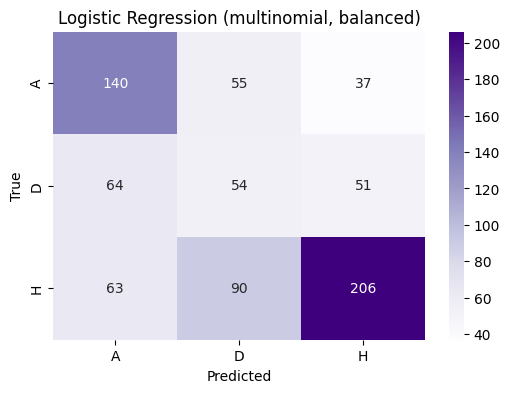

In [39]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix


# ================================
# 4. Ewaluacja na teście
# ================================

best_logreg = grid_logreg.best_estimator_
y_pred_clf = best_logreg.predict(X_test_clf)

acc_log_reg = accuracy_score(y_test_clf, y_pred_clf)
f1m_log_reg = f1_score(y_test_clf, y_pred_clf, average="macro")

print("\n=== Logistic Regression (multinomial, balanced) - TEST ===")
print(f"Accuracy:  {acc_log_reg:.4f}")
print(f"Macro-F1:  {f1m_log_reg:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test_clf, y_pred_clf, target_names=le_log.classes_))

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=le_log.classes_, yticklabels=le_log.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
name = "Logistic Regression (multinomial, balanced)"
plt.title(name)

plt.savefig(RESULTS_PATH / f"{name} - Confusion Matrix", bbox_inches="tight")
plt.show()

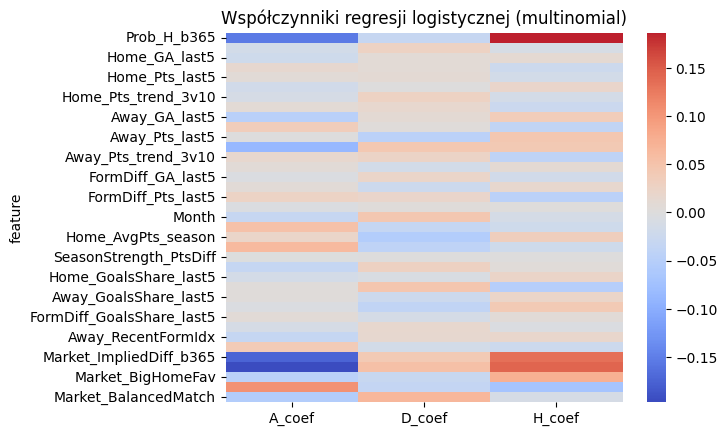

In [ ]:
coeffs = best_logreg.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": X_train_clf.columns,
    "A_coef": coeffs[0],
    "D_coef": coeffs[1],
    "H_coef": coeffs[2]
})

sns.heatmap(coef_df.set_index("feature"), cmap="coolwarm", center=0)
name = "Współczynniki regresji logistycznej (multinomial)"
plt.title(name)

plt.savefig(RESULTS_PATH / (name + ".png"), bbox_inches="tight")
plt.show()

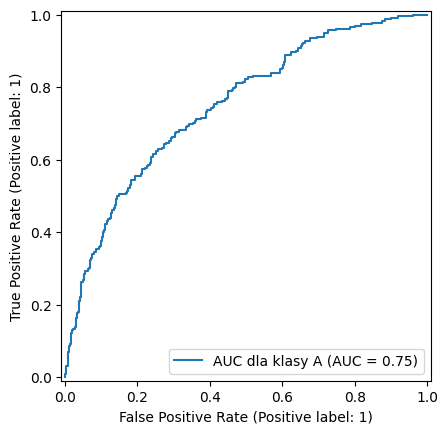

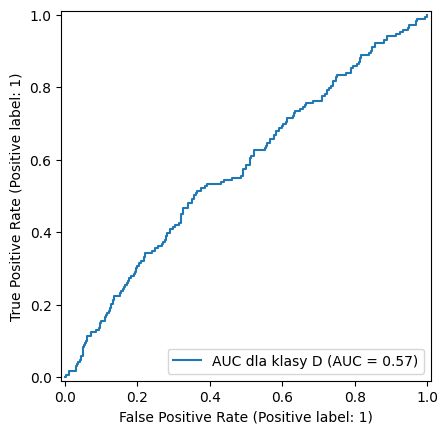

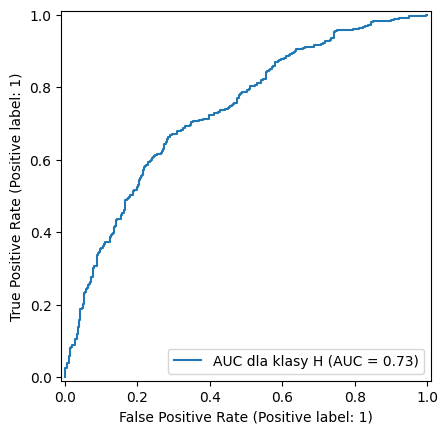

In [9]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize


y_test_bin = label_binarize(y_test_clf, classes=[0, 1, 2])
y_pred_proba = best_logreg.predict_proba(X_test_clf)

# plt.figure(figsize=(10, 5))
for i, cls in enumerate(le_log.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_pred_proba[:, i], name=f"AUC dla klasy {cls}"
    )

plt.show()

# REGERSJA LOGISTYCZNA MODEL BINARNY

In [10]:
# ============================================
#  LOGISTIC REGRESSION - OPCJA BINARNA
#  H = 1,  A/D = 0
# ============================================

# ==========================
# 1. Binarne kodowanie celu
# ==========================

df_bin = df.copy()
df_bin["FTR_bin"] = df_bin["FTR"].map({"H": 1, "D": 0, "A": 0})

y_bin = df_bin["FTR_bin"].values
X_bin = df_bin[X_features].copy()

# ==========================
# 2. Podział train / test
# ==========================

split_date = pd.Timestamp("2022-07-01")
train_mask = df_bin["Date"] < split_date
test_mask  = df_bin["Date"] >= split_date

X_train_bin = X_bin.loc[train_mask].reset_index(drop=True)
X_test_bin  = X_bin.loc[test_mask].reset_index(drop=True)
y_train_bin = y_bin[train_mask]
y_test_bin  = y_bin[test_mask]

print("Train:", X_train_bin.shape, " Test:", X_test_bin.shape)

Train: (2660, 37)  Test: (760, 37)


In [11]:
# ==========================
# 3. Pipeline + GridSearch
# ==========================

logreg_bin = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)
pipe_logreg_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", logreg_bin)
])
param_grid = {
    "model__C": [2, 4, 6, 8, 10]
}
grid_logreg_bin = GridSearchCV(
    estimator=pipe_logreg_bin,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Trenowanie GridSearchCV (wersja binarna)...")
grid_logreg_bin.fit(X_train_bin, y_train_bin)

print("Najlepsze parametry:", grid_logreg_bin.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_logreg_bin.best_score_)

Trenowanie GridSearchCV (wersja binarna)...
Najlepsze parametry: {'model__C': 6}
Najlepszy wynik CV (Macro-F1): 0.6693628128902702


In [12]:
# ==========================
# 4. Wyniki na teście
# ==========================

best_logreg_bin = grid_logreg_bin.best_estimator_
y_pred = best_logreg_bin.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred)
f1_bin = f1_score(y_test_bin, y_pred)

print("\n=== Logistic Regression (Binary) - TEST ===")
print("Accuracy:", round(acc_bin, 4))
print("F1:", round(f1_bin, 4))

print("\n=== Classification report ===")
print(classification_report(
    y_test_bin, y_pred, target_names=["NoHomeWin (A/D)", "HomeWin (H)"])
)


=== Logistic Regression (Binary) - TEST ===
Accuracy: 0.6816
F1: 0.6685

=== Classification report ===
                 precision    recall  f1-score   support

NoHomeWin (A/D)       0.70      0.68      0.69       401
    HomeWin (H)       0.66      0.68      0.67       359

       accuracy                           0.68       760
      macro avg       0.68      0.68      0.68       760
   weighted avg       0.68      0.68      0.68       760



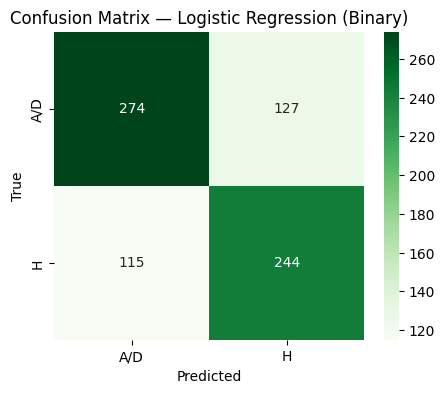

In [13]:
# ==========================
# 5. Confusion Matrix
# ==========================

cm_bin = confusion_matrix(y_test_bin, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Greens",
            xticklabels=["A/D","H"], yticklabels=["A/D","H"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Logistic Regression (Binary)")
plt.show()